In [1]:
import sys
import types
import pickle
import pandas as pd
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import sqlite3 as sql

import morph_analyses as m
from morph_analyses import preprocessing as pp

# Patch for pickles created with pandas < 2.0
# pandas.core.indexes.numeric was removed in pandas 2.0;
# Int64Index, Float64Index, UInt64Index were merged into pd.Index
_numeric_mod = types.ModuleType("pandas.core.indexes.numeric")
_numeric_mod.Int64Index = pd.Index
_numeric_mod.Float64Index = pd.Index
_numeric_mod.UInt64Index = pd.Index
sys.modules["pandas.core.indexes.numeric"] = _numeric_mod

pkl_basedir = pathlib.Path("/mnt/BigDisk/morph/Suite2P_Data")

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [36]:
df = pp.load_session_db(dir='/mnt/BigDisk/morph_vr_data/')
# df = pp.load_session_db()
df = df[df['RewardCount']>40]
# df = df[df['Imaging']==1]
df = df.sort_values(['MouseName','DateTime','SessionNumber'])
# df = df[df["Track"]=="TwoTower_foraging"]
# df = df[(df['ImagingRegion']=='CA1' )|(df['ImagingRegion']=='')]

In [32]:
df.head()

,MouseName,DateFolder,SessionNumber,Track,RewardCount,Imaging,ImagingRegion,DateTime,data file,scanmat,s2pfolder
145,4054010.4,15_06_2018,2,TwoTower_noTimeout,42,1,NaN,2018-06-15,None,None,None
361,4054010.5,15_06_2018,1,TwoTower_noTimeout,49,1,NaN,2018-06-15,None,None,None
363,4054010.5,15_06_2018,2,TwoTower_Timeout,45,1,NaN,2018-06-15,None,None,None
347,4054010.5,17_06_2018,2,TwoTower_Timeout,78,1,NaN,2018-06-17,None,None,None
365,4054010.5,19_06_2018,2,TwoTower_Timeout,57,1,NaN,2018-06-19,None,None,None


In [39]:
mouse_df = df.loc[df['MouseName']==m.mouse_metadata.frequent_w_decision_mice[3],:]
mouse_df.head(50)

,MouseName,DateFolder,SessionNumber,Track,RewardCount,Imaging,ImagingRegion,DateTime,data file,scanmat,s2pfolder
2236,4222169.4,01_08_2019,1,RuningTraining,91,0,NaN,2019-08-01,None,None,None
2240,4222169.4,02_08_2019,1,RuningTraining,200,0,NaN,2019-08-02,None,None,None
2244,4222169.4,04_08_2019,1,RuningTraining,200,0,NaN,2019-08-04,None,None,None
2249,4222169.4,05_08_2019,1,RuningTraining,105,0,NaN,2019-08-05,None,None,None
2302,4222169.4,06_08_2019,1,TwoTower_noTimeout,57,0,CA1,2019-08-06,None,None,None
2303,4222169.4,06_08_2019,2,TwoTower_noTimeout,46,1,CA1,2019-08-06,None,None,None
2326,4222169.4,07_08_2019,1,TwoTower_noTimeout,150,0,,2019-08-07,None,None,None
2348,4222169.4,08_08_2019,0,TwoTower_Timeout,66,0,,2019-08-08,None,None,None
2346,4222169.4,08_08_2019,1,TwoTower_noTimeout,50,0,CA1,2019-08-08,None,None,None
2347,4222169.4,08_08_2019,2,TwoTower_noTimeout,58,1,CA1,2019-08-08,None,None,None


In [5]:
mouse_df.iloc[5]

MouseName                  4343702.1
DateFolder                21_03_2020
SessionNumber                      2
Track              TwoTower_foraging
RewardCount                       67
Imaging                            1
ImagingRegion                    CA1
DateTime         2020-03-21 00:00:00
data file                       None
scanmat                         None
s2pfolder                       None
Name: 3676, dtype: object

In [29]:
mouse = '4343702.1'
date_str = '22_03_2020'
sess_num = 3

pkl_path = pkl_basedir / mouse / f"TwoTower_foraging_{date_str}_{sess_num}.pkl"
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

/tmp/ipykernel_72032/3838316988.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f)
/tmp/ipykernel_72032/3838316988.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f)


In [30]:
data.keys()

dict_keys(['VRDat', 'C', 'S', 'dFF', 'trial_info', 'tstart_inds', 'teleport_inds', 'S_trial_mat', 'occ_trial_mat', 'edges', 'centers'])

In [31]:
data['dFF'].shape

(37732, 2746)

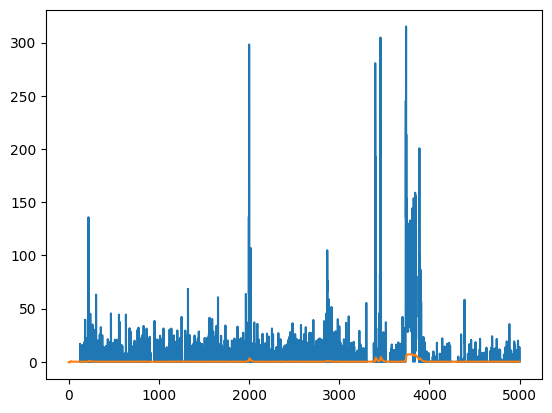

In [36]:
%matplotlib inline
from matplotlib import pyplot as plt
fig, ax = plt.subplots()
ax.plot(data['S'][:5000,1]/15.46)
ax.plot(data['C'][:5000,1])

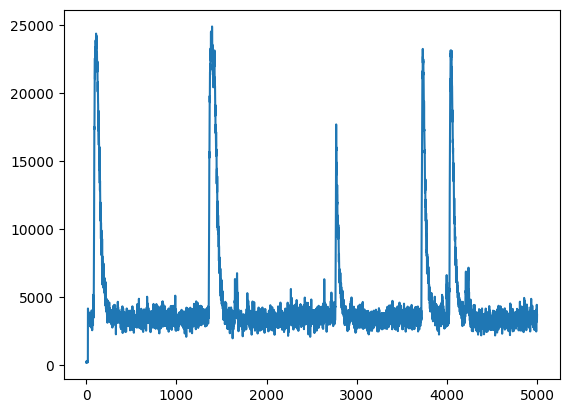

In [37]:
fig, ax = plt.subplots()
ax.plot(data['dFF'][:5000,0])

(200.0, 400.0)

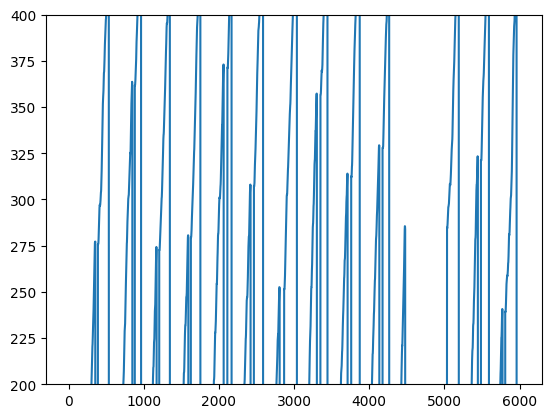

In [22]:


fig, ax = plt.subplots()
ax.plot(data['VRDat']['pos'].iloc[:6000])
ax.set_ylim([200, 400])

In [23]:
data.keys()

dict_keys(['VRDat', 'C', 'S', 'dFF', 'trial_info', 'tstart_inds', 'teleport_inds', 'S_trial_mat', 'occ_trial_mat', 'edges', 'centers'])

In [28]:
data['S'].shape

(20674, 958)

In [25]:
mu_S_mat =data['S_trial_mat'][:30,:,:].mean(axis=0)

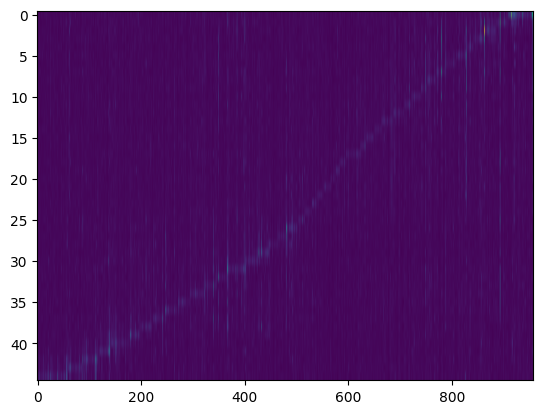

In [27]:
argsort_idx = np.argsort(np.argmax(mu_S_mat,axis=0), axis=0)[::-1]
plt.imshow(mu_S_mat[:,argsort_idx], aspect='auto', cmap='viridis')

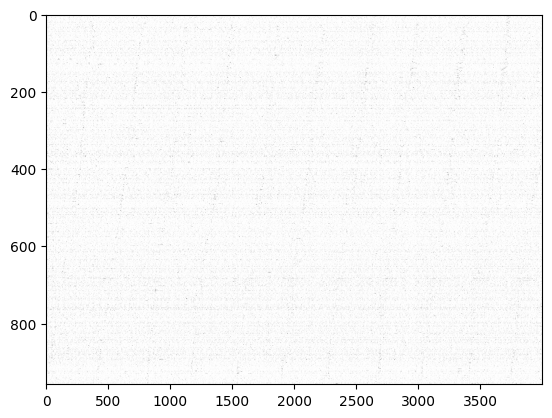

In [53]:
tmp_S = data['S'][~np.isnan(data['S'][:,0]),:]
tmp_S /= np.nanmax(tmp_S, axis=0,keepdims=True)
tmp_S.shape
plt.imshow(tmp_S[:4000,argsort_idx].T, aspect='auto', cmap='Greys',vmax=.2, vmin=0)

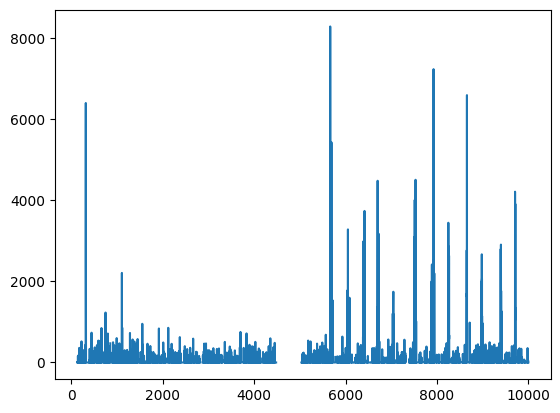

In [54]:
fig,ax = plt.subplots()
ax.plot(data['S'][:10000,0])

In [56]:
a = np.argwhere(np.isnan(data['S'][:,0]))

In [62]:
pos_tmp = data['VRDat']['pos'].loc[np.isnan(data['S'][:,0])]
print(pos_tmp.shape, pos_tmp.min(), pos_tmp.max())

(2727,) -1000.0 -1000.0
